### AlexNet

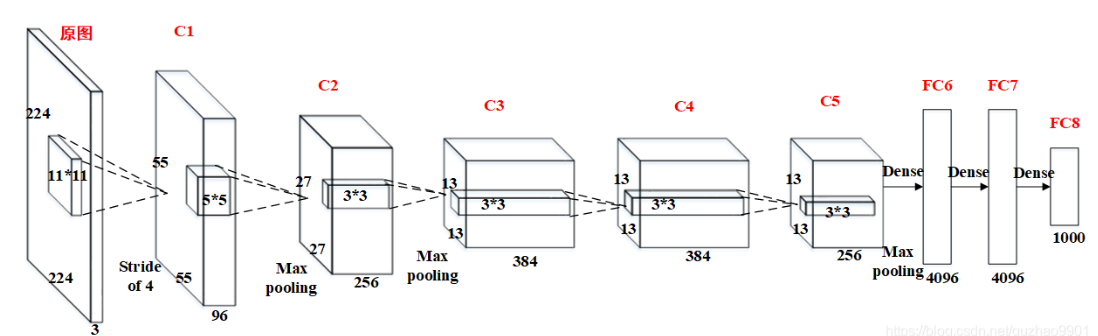

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets,transforms,models
import numpy as np
import matplotlib.pyplot as plt
import imageio
import time
import warnings
import random
import sys
import copy
import json
from PIL import Image
import os

d:\Anconda\envs\Paddle_tutorial\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**卷积结果计算公式:**

* 长度:${H_2 = \frac{H_1-F_H+2P}{S}+1}$

* 宽度:${W_2 = \frac{W_1-F_W+2P}{S}+1}$

* 其中 ${W1}$、${H1}$ 表示输入的宽度、长度; ${W2}$、${H2}$ 表示输出特征图的宽度、长度;${F}$ 表示卷积核长和宽的大小; ${S}$ 表示滑动窗口的步长; ${P}$ 表示边界填充(边界填充) 

In [2]:
import torch
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self) -> None:
        super(AlexNet, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 96, 11, 4, 2),  # Input: (3, 224, 224), Output: (96, 55, 55) 
            nn.ReLU(),
            nn.MaxPool2d(3, 2)  # Output: (96, 27, 27) 
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(96, 256, 5, 1, 2),  # Output: (256, 27, 27) #第二层的不成时1，padding是2 
            nn.ReLU(),
            nn.MaxPool2d(3, 2)  # Output: (256, 13, 13) 
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(256, 384, 3, 1, 1),  # Output: (384, 13, 13) 
            nn.ReLU()
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(384, 384, 3, 1, 1),  # Output: (384, 13, 13)
            nn.ReLU()
        )
        
        self.conv5 = nn.Sequential(
            nn.Conv2d(384, 256, 3, 1, 1),  # Output: (256, 13, 13)
            nn.ReLU(),
            nn.MaxPool2d(3, 2)  # Output: (256, 6, 6)
        )
        
        self.dense = nn.Sequential(
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout()
        )
        
        self.out = nn.Linear(4096, 102)  # Output: 102 classes
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = x.view(x.size(0), -1)  # Flatten operation
        dense = self.dense(x)
        output = self.out(dense)
        return output


In [3]:
model = AlexNet()
model

AlexNet(
  (conv1): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (conv4): Sequential(
    (0): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (conv5): Sequential(
    (0): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dense): Sequential(
    (0): Linear(in_features=9216, out_features=4096, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)

In [4]:
string = 'ABCD'
print(string)
s = 'E'
print(string + s)

ABCD
ABCDE


In [5]:
data_dir = './dataset/flower_data'
train_dir = data_dir+'/train'
print(train_dir)
test_dir = data_dir+'/valid'
print(test_dir)


./dataset/flower_data/train
./dataset/flower_data/valid


这段代码定义了基于 PyTorch `torchvision` 库的**数据预处理和增强策略**，通常用于深度学习图像分类任务（特别是迁移学习，如使用 ResNet, VGG, AlexNet 等预训练模型）。

它将数据处理分为了两个阶段：**训练集 (`train`)** 和 **验证集 (`valid`)**。

### 1. 核心结构：`data_transforms` 字典
这是一个字典，包含两个键：
*   `'train'`: 对应训练阶段的数据变换管道。目的是**增加数据多样性**，防止模型过拟合，提高泛化能力。
*   `'valid'`: 对应验证/测试阶段的数据变换管道。目的是**标准化输入**，确保评估结果的一致性和公平性，**不使用随机增强**。

---

### 2. 训练集变换 (`'train'`) 详解
训练集的变换顺序非常重要，因为某些操作（如 `ToTensor`）会改变数据的类型和范围。

1.  **`transforms.RandomRotation(45)`**:
    *   **作用**: 随机旋转图像。
    *   **细节**: 旋转角度在 $[-45^\circ, 45^\circ]$ 之间随机选择。这能让模型学会识别不同角度的物体，增强旋转不变性。

2.  **`transforms.CenterCrop(224)`**:
    *   **作用**: 从图像中心裁剪出 $224 \times 224$ 的区域。
    *   **注意**: 这里直接中心裁剪在训练集中略显少见（通常训练集用 `RandomResizedCrop` 来同时实现缩放和随机裁剪以增加多样性），但这样写也能保证输入尺寸固定为 224。如果原图小于 224，可能会报错或填充（取决于具体版本和图像加载方式，通常要求原图大于 224）。

3.  **`transforms.RandomHorizontalFlip(p=0.5)`**:
    *   **作用**: 以 50% 的概率随机水平翻转图像。
    *   **意义**: 对于大多数物体（如猫、狗、车），左右翻转不改变其类别，这是最常用的增强手段之一。

4.  **`transforms.RandomVerticalFlip(p=0.5)`**:
    *   **作用**: 以 50% 的概率随机垂直翻转图像。
    *   **注意**: **需谨慎使用**。对于自然场景图像（如天空在上、地面在下），垂直翻转会破坏物理常识（倒立的图），可能导致模型学习困难。通常仅在物体具有上下对称性或特定任务（如卫星图、显微镜图）中使用。

5.  **`transforms.ColorJitter(...)`**:
    *   **作用**: 随机调整图像的颜色属性。
    *   **参数**:
        *   `brightness=0.2`: 亮度在 $[0.8, 1.2]$ 之间随机变化。
        *   `contrast=0.1`: 对比度在 $[0.9, 1.1]$ 之间随机变化。
        *   `saturation=0.1`: 饱和度在 $[0.9, 1.1]$ 之间随机变化。
        *   `hue=0.1`: 色调在 $[-0.1, 0.1]$ 之间随机变化。
    *   **意义**: 让模型对光照条件和颜色变化更鲁棒。

6.  **`transforms.RandomGrayscale(p=0.025)`**:
    *   **作用**: 以 2.5% 的概率将图像转换为灰度图（R=G=B）。
    *   **意义**: 强迫模型不仅仅依赖颜色特征，也要学习形状和纹理特征。

7.  **`transforms.ToTensor()`**:
    *   **作用**: **关键步骤**。
        *   将 PIL Image 或 NumPy array (H, W, C) 转换为 PyTorch Tensor (C, H, W)。
        *   将像素值范围从 $[0, 255]$ 缩放到 $[0.0, 1.0]$ (浮点数)。
    *   **注意**: 此步骤必须在 `Normalize` 之前，且必须在所有基于像素值的增强（如 ColorJitter, Rotation）之后（因为那些操作通常需要 PIL 对象或整数像素值）。

8.  **`transforms.Normalize(...)`**:
    *   **作用**: 对每个通道进行标准化（归一化）。
    *   **公式**: $output = (input - mean) / std$
    *   **数值来源**: `[0.485, 0.456, 0.406]` 和 `[0.229, 0.224, 0.225]` 是 **ImageNet 数据集** 的均值和标准差。
    *   **意义**: 如果使用在 ImageNet 上预训练的模型（如 ResNet50），**必须**使用这些特定的数值进行标准化，否则预训练权重将失效，导致模型无法收敛或效果极差。

---

### 3. 验证集变换 (`'valid'`) 详解
验证集的处理必须是**确定性**的（Deterministic），不能包含随机性，以保证每次评估结果一致。

1.  **`transforms.Resize(256)`**:
    *   **作用**: 将图像的短边缩放到 256 像素，长边保持比例缩放。
    *   **目的**: 为接下来的中心裁剪做准备，确保图像足够大。

2.  **`transforms.CenterCrop(224)`**:
    *   **作用**: 从缩放后的图像中心裁剪出 $224 \times 224$ 的区域。
    *   **对比**: 训练集有时会用随机裁剪，而验证集统一用中心裁剪，代表取图像的“主体”部分进行评估。

3.  **`transforms.ToTensor()`** & **`transforms.Normalize(...)`**:
    *   **作用**: 与训练集完全相同。将数据转换为 Tensor 并使用 ImageNet 统计量进行标准化，以匹配预训练模型的输入要求。

### 总结
这段代码构建了一个标准的**迁移学习数据流水线**：
*   **训练时**：通过旋转、翻转、色彩抖动等手段“制造”更多样化的数据，防止过拟合，最后转为 Tensor 并归一化。
*   **验证时**：仅做必要的尺寸调整和归一化，确保评估稳定。
*   **适用场景**：基于 ImageNet 预训练权重的图像分类任务，输入图像最终被处理为 `(3, 224, 224)` 的 Tensor。

In [ ]:
data_transforms = {
    'train':transforms.Compose([
        transforms.RandomRotation(45),#随机旋转, -45到45之间随机
        transforms.CenterCrop(224),#从中心开始裁剪
        transforms.RandomHorizontalFlip(p=0.5),#随机水平翻转,选择一个概率
        transforms.RandomVerticalFlip(p=0.5),#随机垂直旋转
        transforms.ColorJitter(brightness=0.2,contrast=0.1,saturation=0.1,hue=0.1), # 参数1为亮度,参数2为对比度,参数3为饱和度,参数4为色相
        transforms.RandomGrayscale(p=0.025),#概率转化成灰度率，3通道就是R=G=B
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])#均值, #标准差
    ]),
    'valid':transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])#均值, #标准差
    ])
}

In [8]:
batch_size = 8

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir,x), data_transforms[x]) for x in ['train', 'valid']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x],batch_size = batch_size, shuffle=True) for x in ['train', 'valid']}
dataset_sizes = {x:len(image_datasets[x]) for x in ['train','valid']}
class_names = image_datasets['train'].classes
class_names

['1',
 '10',
 '100',
 '101',
 '102',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '4',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '5',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '6',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '7',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '8',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '9',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99']

In [7]:
image_datasets

{'train': Dataset ImageFolder
     Number of datapoints: 6552
     Root location: ./dataset/flower_data\train
     StandardTransform
 Transform: Compose(
                RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
                CenterCrop(size=(224, 224))
                RandomHorizontalFlip(p=0.5)
                RandomVerticalFlip(p=0.5)
                ColorJitter(brightness=[0.8, 1.2], contrast=[0.9, 1.1], saturation=[0.9, 1.1], hue=[-0.1, 0.1])
                RandomGrayscale(p=0.025)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 'valid': Dataset ImageFolder
     Number of datapoints: 818
     Root location: ./dataset/flower_data\valid
     StandardTransform
 Transform: Compose(
                Resize(size=256, interpolation=bilinear, max_size=None, antialias=None)
                CenterCrop(size=(224, 224))
                ToTensor()
                Normalize(mea

In [8]:
with open ('./dataset/flower_data/cat_to_name.json','r') as f:
    cat_to_name = json.load(f)

In [9]:
cat_to_name

{'21': 'fire lily',
 '3': 'canterbury bells',
 '45': 'bolero deep blue',
 '1': 'pink primrose',
 '34': 'mexican aster',
 '27': 'prince of wales feathers',
 '7': 'moon orchid',
 '16': 'globe-flower',
 '25': 'grape hyacinth',
 '26': 'corn poppy',
 '79': 'toad lily',
 '39': 'siam tulip',
 '24': 'red ginger',
 '67': 'spring crocus',
 '35': 'alpine sea holly',
 '32': 'garden phlox',
 '10': 'globe thistle',
 '6': 'tiger lily',
 '93': 'ball moss',
 '33': 'love in the mist',
 '9': 'monkshood',
 '102': 'blackberry lily',
 '14': 'spear thistle',
 '19': 'balloon flower',
 '100': 'blanket flower',
 '13': 'king protea',
 '49': 'oxeye daisy',
 '15': 'yellow iris',
 '61': 'cautleya spicata',
 '31': 'carnation',
 '64': 'silverbush',
 '68': 'bearded iris',
 '63': 'black-eyed susan',
 '69': 'windflower',
 '62': 'japanese anemone',
 '20': 'giant white arum lily',
 '38': 'great masterwort',
 '4': 'sweet pea',
 '86': 'tree mallow',
 '101': 'trumpet creeper',
 '42': 'daffodil',
 '22': 'pincushion flower',
 

In [ ]:
def im_convert(tensor):
    """将张量转换为图像格式"""
    image = tensor.cpu().clone().detach()  # 克隆张量，并确保在 CPU 上进行处理
    image = image.numpy().squeeze()  # 转换为 NumPy 数组
    image = image.transpose(1, 2, 0)  # 交换维度以得到 HxWxC 的格式
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))  # 去归一化
    image = np.clip(image, 0, 1)  # 将值裁剪到 [0, 1] 的范围
    
    return image


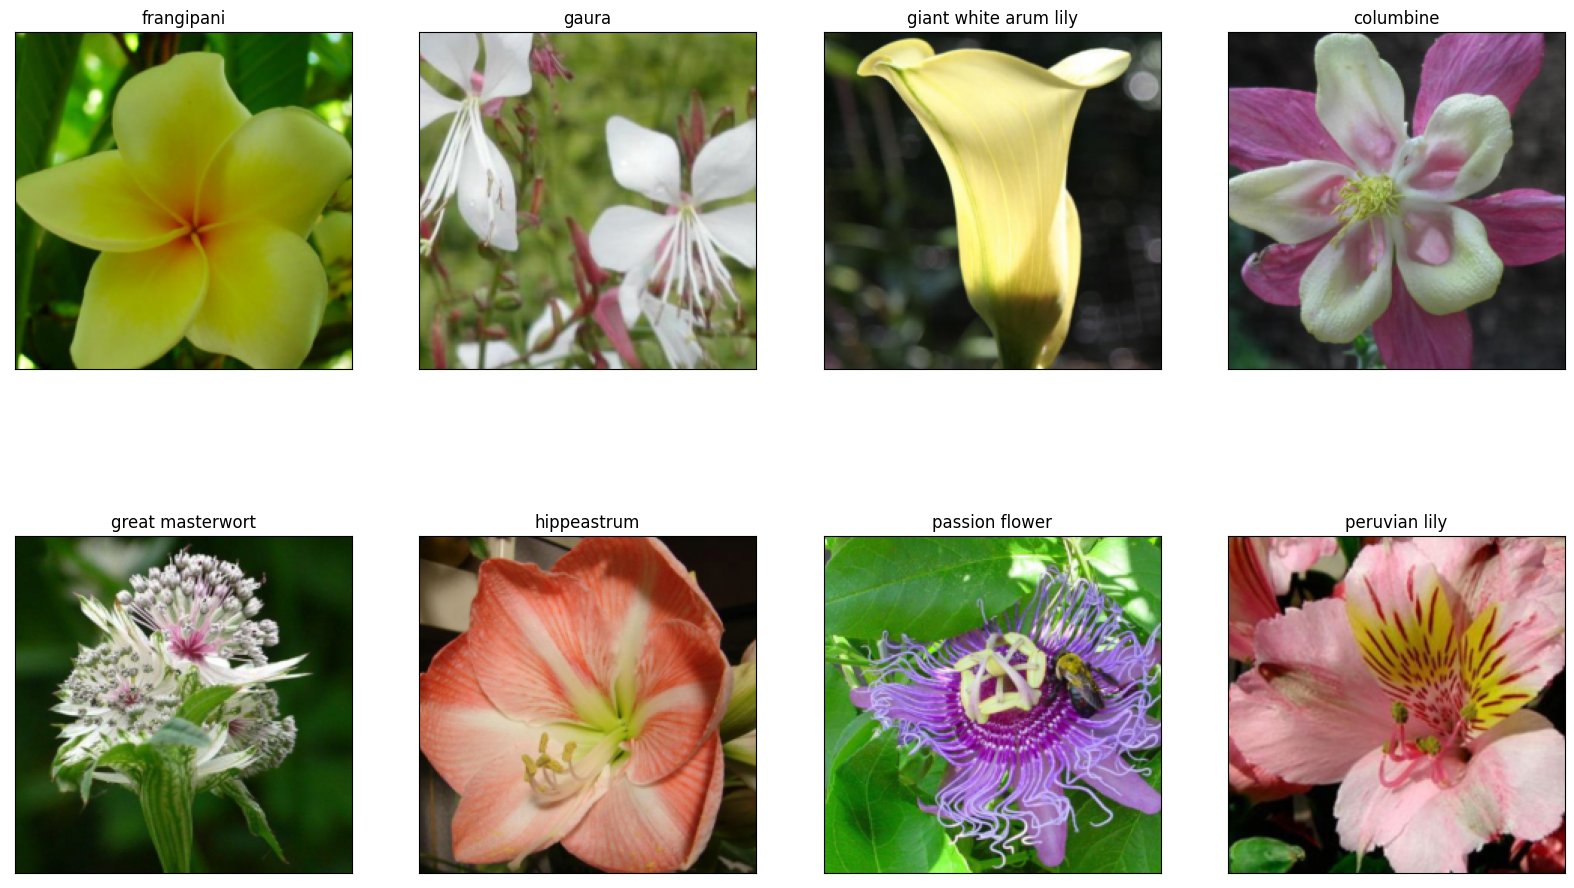

In [11]:
fig = plt.figure(figsize=(20,12))
columns  = 4
rows = 2

dataiter = iter(dataloaders['valid'])
inputs, classes = next(dataiter)

for idx in range(columns*rows):
    ax = fig.add_subplot(rows, columns, idx+1, xticks = [], yticks = [])
    ax.set_title(cat_to_name[str(int(class_names[classes[idx]]))])
    plt.imshow(im_convert(inputs[idx]))

plt.show()

In [12]:
train_on_GPU = torch.cuda.is_available()

if not train_on_GPU:
    print('CUDA is not available. Training on CPU...')
else:
    print('CUDA is available. Training on GPU...')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

CUDA is available. Training on GPU...


In [13]:
model = model.to(device)

params_to_update = model.parameters()

for name, param in model.named_parameters():  # 使用 named_parameters() 方法
        if param.requires_grad == True:
            print("\t", name)

	 conv1.0.weight
	 conv1.0.bias
	 conv2.0.weight
	 conv2.0.bias
	 conv3.0.weight
	 conv3.0.bias
	 conv4.0.weight
	 conv4.0.bias
	 conv5.0.weight
	 conv5.0.bias
	 dense.0.weight
	 dense.0.bias
	 dense.3.weight
	 dense.3.bias
	 out.weight
	 out.bias


In [ ]:
optimizer_ft = optim.Adam(params_to_update, lr = 1e-4 )

scheduler = optim.lr_scheduler.StepLR(optimizer_ft,step_size=20, gamma=0.1) #学习率每10个epoch衰减为原来的1/10

criterion = nn.CrossEntropyLoss()

In [15]:
import time
import copy
import torch

def train_model(model, dataloaders, criterion, optimizer_ft, scheduler, num_epochs=25, filename='Alexnet.pth'):
    since = time.time()
    best_acc = 0

    model.to(device)

    val_acc_history = []
    train_acc_history = []
    valid_losses = []
    train_losses = []
    test_losses = []
    LRs = [optimizer_ft.param_groups[0]['lr']]

    best_model_wts = copy.deepcopy(model.state_dict())  # 最好模型权重文件

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-'*10)

        # 训练和验证
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # 训练模式
            else:
                model.eval()  # 验证模式

            running_loss = 0.0
            running_corrects = 0.0

            # 遍历数据
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # 梯度清零
                optimizer_ft.zero_grad()

                # 只有训练的时候计算和更新梯度
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    # 训练阶段更新权重
                    if phase == 'train':
                        loss.backward()
                        optimizer_ft.step()

                # 计算损失
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # 保存最佳模型
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # state = {
                #     'state_dict': model.state_dict(),
                #     'best_acc': best_acc,
                #     'optimizer': optimizer_ft.state_dict(),
                #     'scheduler': scheduler.state_dict(),
                #     'epoch': epoch
                # }
                torch.save(best_model_wts, filename)
            
            if phase == 'valid':
                val_acc_history.append(epoch_acc)
                valid_losses.append(epoch_loss)
                scheduler.step(epoch_loss)
            
            if phase == 'train':
                train_acc_history.append(epoch_acc)
                train_losses.append(epoch_loss)

        print('Optimizer learning rate: {:.7f}'.format(optimizer_ft.param_groups[0]['lr']))
        LRs.append(optimizer_ft.param_groups[0]['lr'])
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # 训练完后用最好的一次作为最终结果
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_acc_history, valid_losses, train_losses, LRs


In [ ]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs = train_model(
    model, 
    dataloaders, 
    criterion, 
    optimizer_ft, 
    scheduler,  # <- 确保传递 scheduler 参数
    num_epochs=100, 
    filename='Alexnet1.pth' 
)

Epoch 0/99
----------
train Loss: 4.3799 Acc: 0.0401
valid Loss: 4.1403 Acc: 0.0513


d:\Anconda\envs\Paddle_tutorial\lib\site-packages\torch\optim\lr_scheduler.py:163: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Optimizer learning rate: 0.0001000

Epoch 1/99
----------
train Loss: 3.9906 Acc: 0.0777
valid Loss: 3.8922 Acc: 0.0880
Optimizer learning rate: 0.0001000

Epoch 2/99
----------
train Loss: 3.7406 Acc: 0.1009
valid Loss: 3.8806 Acc: 0.0758
Optimizer learning rate: 0.0001000

Epoch 3/99
----------
train Loss: 3.5051 Acc: 0.1316
valid Loss: 3.6539 Acc: 0.1125
Optimizer learning rate: 0.0001000

Epoch 4/99
----------
train Loss: 3.2668 Acc: 0.1760
valid Loss: 3.5452 Acc: 0.1308
Optimizer learning rate: 0.0001000

Epoch 5/99
----------
train Loss: 3.0998 Acc: 0.2016
valid Loss: 3.5585 Acc: 0.1540
Optimizer learning rate: 0.0001000

Epoch 6/99
----------
train Loss: 2.9420 Acc: 0.2398
valid Loss: 3.5336 Acc: 0.1357
Optimizer learning rate: 0.0001000

Epoch 7/99
----------
train Loss: 2.7928 Acc: 0.2712
valid Loss: 3.2896 Acc: 0.1858
Optimizer learning rate: 0.0001000

Epoch 8/99
----------
train Loss: 2.6638 Acc: 0.2972
valid Loss: 3.5497 Acc: 0.1809
Optimizer learning rate: 0.0001000

Epoc